## Imports

In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import os
import sys
import matplotlib.pyplot as plt

os.chdir("/home/patrick/ansermodelling")

from models.FFNN_network import FFNN
from data.anser_dataset import *
from models.train import *


## Dataset

In [2]:
train_loader, test_loader = make_dataloaders("data/dataset.npz", normalise_data = True)

In [3]:
model = FFNN(input_dim=8, output_dim=6, hidden_dims=[256,256,256])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=400)
loss_fn = PoseLoss()

In [4]:
history = train(model, train_loader, test_loader, optimizer, scheduler = scheduler, epochs=400, loss_fn = loss_fn, print_losses = True)

epoch 	 Training Loss 	 Test Loss 	 e_p test 	 e_n test
1 	 0.0227 	  0.0125 	 60.3970 	 29.9939
2 	 0.0094 	  0.0071 	 47.4376 	 21.3332
3 	 0.0066 	  0.0056 	 40.9365 	 18.9550
4 	 0.0052 	  0.0045 	 35.6006 	 16.5726
5 	 0.0044 	  0.0042 	 32.5349 	 16.9989
6 	 0.0039 	  0.0043 	 35.4890 	 16.1677
7 	 0.0036 	  0.0032 	 29.1389 	 14.1339
8 	 0.0035 	  0.0035 	 28.8859 	 14.8422
9 	 0.0031 	  0.0030 	 28.8023 	 13.1282
10 	 0.0029 	  0.0029 	 27.9509 	 12.9535
11 	 0.0028 	  0.0028 	 28.7025 	 12.4560
12 	 0.0027 	  0.0028 	 27.3968 	 12.8162
13 	 0.0026 	  0.0025 	 26.0622 	 11.7448
14 	 0.0025 	  0.0027 	 28.4732 	 11.8963
15 	 0.0024 	  0.0024 	 23.3635 	 12.1159
16 	 0.0024 	  0.0024 	 26.2944 	 11.2635
17 	 0.0023 	  0.0023 	 25.7059 	 11.2390
18 	 0.0023 	  0.0024 	 25.9827 	 11.3495
19 	 0.0022 	  0.0022 	 24.4326 	 11.0178
20 	 0.0021 	  0.0022 	 25.7133 	 10.8135
21 	 0.0021 	  0.0022 	 24.6539 	 11.0071
22 	 0.0021 	  0.0022 	 23.4810 	 11.2104
23 	 0.0020 	  0.0022 	 23.55

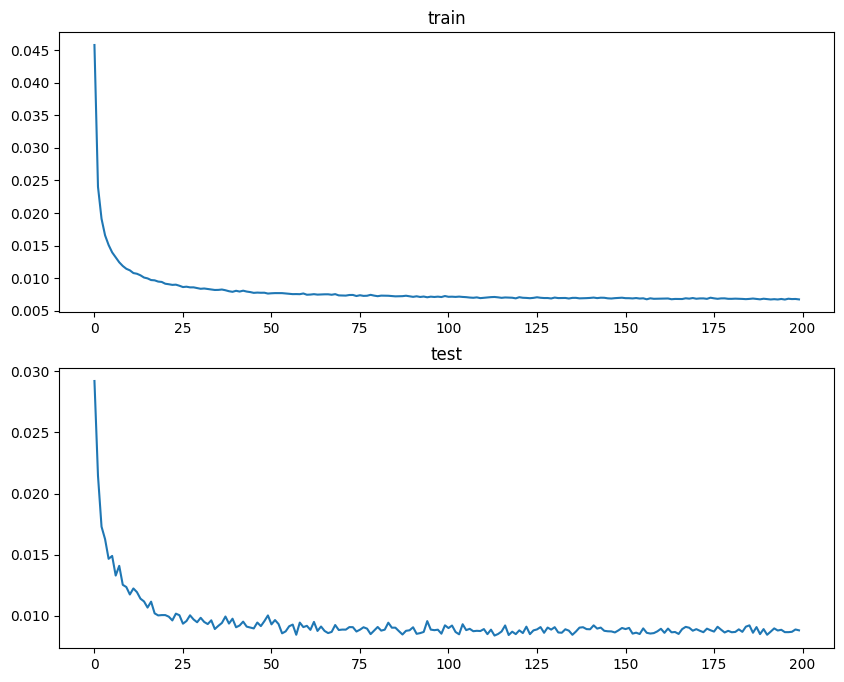

In [13]:
fig, axes = plt.subplots(2,figsize=(10, 8))
axes[0].plot(train_losses)
axes[0].set_title("train")
axes[1].plot(test_losses)
axes[1].set_title("test")
plt.show()
